# Assignment 7: Dimensionality Reduction with Principal Component Analysis

#### ⚠ <span style="color:red">**Please read the instructions and doc strings carefully, they are designed to help you!**</span> ⚠

## Submission Info

- Implement your solution by completing the code below
- Locations are marked with `# YOUR CODE HERE` and `raise NotImplementedError()`
- You will score points for providing a correct implementation / solution
- Exercises can be solved with given imports. Usage of standard Python libraries is allowed, but installing any additional packages or external dependencies is prohibited and will result in failing the exercise. If in doubt, don't use additional imports.
- Please submit your solution as a Jupyter notebook (.ipynb) and as a PDF created from the (executed) Jupyter notebook.
- Rename the file according to `<matriculation-number>_<assignment-number>_<filename>.ipynb` (e.g. for student with matriculation number 123456 for assignment 1 and filename intro.ipynb: `123456_1_intro.ipynb`) and similarly for the PDF.
- Submit the corresponding files to ILIAS


### Additional information for this assignment
- Remember to test to run your notebook top to bottom, as this is the way we will evaluate it!
- Some functions contain typing information (e.g. ``foo: list`` -> the variable ``foo`` is a ``list``). Please make sure your implementation uses the same types in function parameters and return values. For more information take a look at the at the [python typing documention](https://mypy.readthedocs.io/en/stable/).
- Some cells may be empty or only contain testing statements (see below) and are used for later evaluation. Do **not** modify or delete them.
- We provide some tests (most often ``assert`` statements) for you to check whether your implementation is correct. However, most tests are hidden, thus remember to **carefully** test the corner cases (e.g. different input parameters) of your implementation!
- <span style="color:green">**Hint**</span>: ``np.linalg.eig`` is a useful NumPy function.

## Setting up the coding environment

For all coding exercises, we use Python 3. Create a virtual environment and install the libraries specified in the requirements from the first assignment via ```python3 -m pip install -r requirements.txt```. *Do not use any additional python packages*.

Now start the notebook and select the correct python kernel (the environment) and make sure that the imports run without error. The following imports should not throw any errors:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

---

<span style="color:red">Please also inlcude your name and matriculation number here:

## Data exploration

We will use a dataset containing greyscale images of faces which were recorded between April 1992 and April 1994 at the AT&T lab. The resultion of the images is 64x64 so we are dealing with 4096 values per image. We would like to reduce the dimensionality of the dataset using Principal Component Analysis (PCA).

In [2]:
dataset = fetch_olivetti_faces(data_home="./")
data = dataset.data
print(data.shape)

(400, 4096)


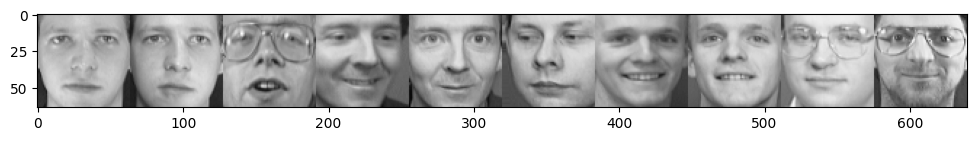

In [3]:
fig = plt.figure(figsize=(12, 12))
plt.imshow(np.concatenate(dataset.data.reshape((-1, 64, 64))[:64:7], axis=1), cmap="gray")
plt.show()

## <span style="color:red">[TODO]</span>  Compute the covariance matrix (2 pts)

In [4]:
# subtract mean from data
mean_face = np.mean(data, axis=0)
shifted_data = data - mean_face

In [5]:
def compute_covariance(shifted_data):
    """
    Compute the covariance matrix of the data

    Normalize the covariance with the factor 1 / (n - 1) where n is the number of samples.
    If you use an existing function, make sure you do not normalize twice. The scale of the
    covariance matrix does not influence the principal components but it does influence the
    eigenvalues.

    Args: 
        data: A n x k array with the shifted data.
    
    Returns:
        A k x k array with the covariance matrix.
    """
    ### BEGIN SOLUTION
    cov = np.matmul(shifted_data.T, shifted_data) / (shifted_data.shape[0] - 1)
    # Alternatively, you can use np.cov with bias=False and ddof=None to get the same result.
    # cov = np.cov(data.T, bias=False, ddof=None)
    return cov
    ### END SOLUTION

In [6]:
# Check that covariance matrix is correctly computed.
cov_matrix = compute_covariance(shifted_data)
assert np.sum(np.abs(cov_matrix[:2, :2] - np.array([[0.0326506,  0.03229796], [0.03229796, 0.03591166]]))) < 1.0e-6
### BEGIN HIDDEN TESTS
test_data = np.arange(100).reshape(20, 5)
def test_covariance(data):
    student_answer = compute_covariance(data - np.mean(data, axis=0))
    correct_mat = np.cov(data.T)
    return np.sum(np.abs(student_answer - correct_mat)) < 1.0e-06
assert test_covariance(test_data)
### END HIDDEN TESTS

## <span style="color:red">[TODO]</span>  Compute the principal components (6 pts)

Important: Because we are dealing with image data, we **do not standardize the dataset** as there is a natural common scale of all features. However, when calculating the covariance matrix, we still take the mean of the data into account, of course.

In [7]:
def compute_pca(cov):
    """
    Compute the principal components of the data.


    Args:
        cov: An k x k array with the covariance matrix.

    Returns:
        - k eigenvalues ordered from largest to smallest
        - unit length k x k principal components (along columns) ordered according 
            to the corresponding eigenvalues
    """
    ### BEGIN SOLUTION
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    ordering = np.flip(np.argsort(eigenvalues))
    eigenvalues = eigenvalues[ordering]
    eigenvectors = eigenvectors[:, ordering]
    return eigenvalues, eigenvectors
    ### END SOLUTION

In [8]:
# Calculate the covariance matrix and the principal components (NOTE: This can take a couple of minutes...)
eigenvalues, eigenvectors = compute_pca(compute_covariance(shifted_data))
# As the covariance matrix is symmetric, the components of the eigenvalues and eigenvectors are real, so we don't need the complex parts
eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real
# Ordered eigenvalues
print(eigenvalues[:5])

[18.840176  11.071762   6.3046145  3.9545841  2.8560426]


In [9]:
# Check that eigenvalues and eigenvectors are correctly returned
assert np.sum(np.abs(eigenvalues[:5] - np.array([18.8401758, 11.07176208, 6.30461472, 3.95458409, 2.85604263]))) < 1.0e-6
assert np.sum(np.abs(eigenvectors[:2, :2] - np.array([[-0.0041911, 0.02859139], [-0.0071095, 0.03328836]]))) < 1.0e-6
### BEGIN HIDDEN TESTS
test_data = np.arange(100).reshape(20, 5)

def test_principal_components(data):
    student_val, student_vec = compute_pca(np.cov(data.T, bias=True))
    cov = np.cov(data.T, bias=True)
    correct_val, correct_vec = np.linalg.eig(cov)
    ordering = np.flip(np.argsort(correct_val))
    correct_val = correct_val[ordering]
    correct_vec = correct_vec[:, ordering]
    return (np.sum(np.abs(student_val - correct_val)) < 1.0e-06) & (np.sum(np.abs(student_vec - correct_vec)) < 1.0e-06)
assert test_principal_components(test_data)
### END HIDDEN TESTS

## <span style="color:red">[TODO]</span>  Compute the explained variance (1 pts)

In [10]:
def explained_variance(eigenvalues):
     """ 
     Compute the explained variance for each component given the eigenvalues.

     Args:
     eigenvalues: A k array of eigenvalues of the covariance matrix in decreasing order.

     Returns:
          A k array of the percentage of variance explained by each corresponding component.
     """
     ### BEGIN SOLUTION
     return eigenvalues / np.sum(eigenvalues) * 100
     ### END SOLUTION

In [11]:
# Percentage of variance being explained by each principal component
print(explained_variance(eigenvalues)[:5])

[23.812729  13.993971   7.9686136  4.998331   3.609848 ]


In [12]:
assert np.sum(np.abs(explained_variance(eigenvalues)[:5] - np.array([23.81273, 13.99397, 7.96861, 4.99833, 3.60985]))) < 1.0e-5
### BEGIN HIDDEN TESTS
test_data = np.arange(100).reshape(20, 5)

def test_variance(data):
    student_var = explained_variance(compute_pca(np.cov(data.T, bias=True))[0])
    cov = np.cov(data.T, bias=False)
    correct_val, correct_vec = np.linalg.eig(cov)
    ordering = np.flip(np.argsort(correct_val))
    correct_val = correct_val[ordering]
    correct_variance = []
    for i in correct_val:
         correct_variance.append((i/sum(correct_val))*100)
    return np.sum(np.abs(student_var - correct_variance)) < 1.0e-06
assert test_variance(test_data)
### END HIDDEN TESTS

How many PCA components do we need to explain the variance of the data sufficiently well? We can look at the cumulative explained variance to answer this question.

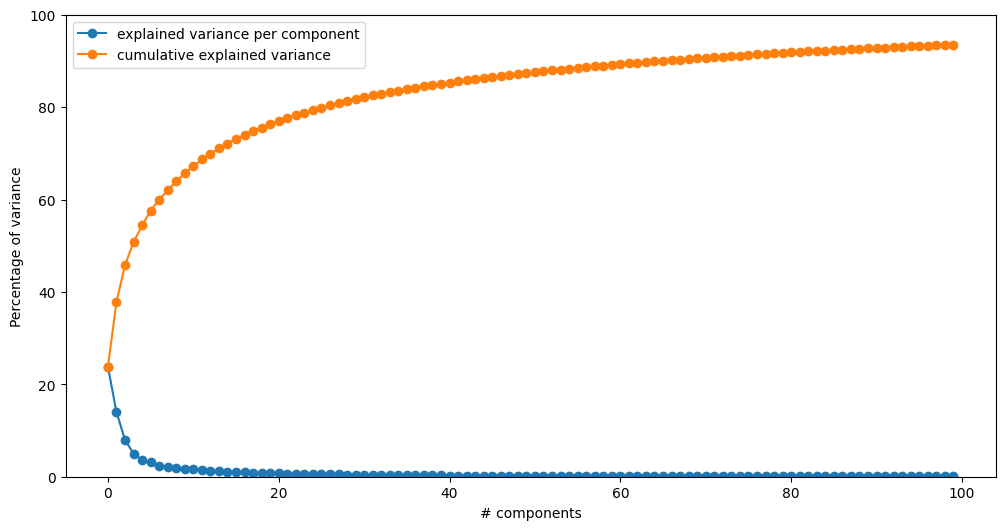

In [13]:
fig = plt.figure(figsize=(12, 6))
exp_var = explained_variance(eigenvalues)
cum_exp_var = np.cumsum(exp_var)
plt.plot(exp_var[:100], label="explained variance per component", marker="o")
plt.plot(cum_exp_var[:100], label="cumulative explained variance", marker="o")
plt.xlabel("# components")
plt.ylabel("Percentage of variance")
plt.ylim(0, 100)
plt.legend()
plt.show()

## <span style="color:red">[TODO]</span> Project to two dimensions (2 pts)

We now project the high-dimensional data down to two dimensions.

In [14]:
def project_to_principal_components(shifted_data, pc):
    """ 
    Project on selected principal components.

    Args:
        shifted_data: An n x k array with shifted data .
        pc: A k x m array of the m selected principal component(s) of dim k on which to project the data.
    
    Returns:
        Data projected to the given component(s) in an n x m array.
    """ 
    ### BEGIN SOLUTION
    return shifted_data.dot(pc)
    ### END SOLUTION

In [15]:
projected_data = project_to_principal_components(shifted_data, eigenvectors[:, :2])

In [16]:
assert np.sum(np.abs(projected_data[:2, :2] - np.array([[-6.4326123, 0.7036688], [-1.0758942, 6.6973326]]))) < 1.0e-5
### BEGIN HIDDEN TESTS
test_data = np.arange(100).reshape(20, 5)

def test_projection(data, num_components):
    student_proj = project_to_principal_components(data - data.mean(axis=0), compute_pca(np.cov(data.T, bias=True))[1][:, :num_components])
    cov = np.cov(data.T, bias=False)
    correct_val, correct_vec = np.linalg.eig(cov)
    ordering = np.flip(np.argsort(correct_val))
    correct_vec = correct_vec[:, ordering]
    correct_proj = (data - np.mean(data, axis=0)).dot(correct_vec[:, :num_components])
    return np.sum(np.abs(student_proj) - np.abs(correct_proj)) < 1.0e-06
assert test_projection(test_data, 1)
assert test_projection(test_data, 2)
### END HIDDEN TESTS

We now plot the projections on the first two principal components as x and y coordinates. The dataset contains labels that correspond to different persons. A person is uniquely identified by a combination of color and marker style in the plot. You should see that the clusters corresponding to different persons heavily overlap. Why was this to be expected? (Hint: Not only the person but also the lighting and angle can be different in different images.)

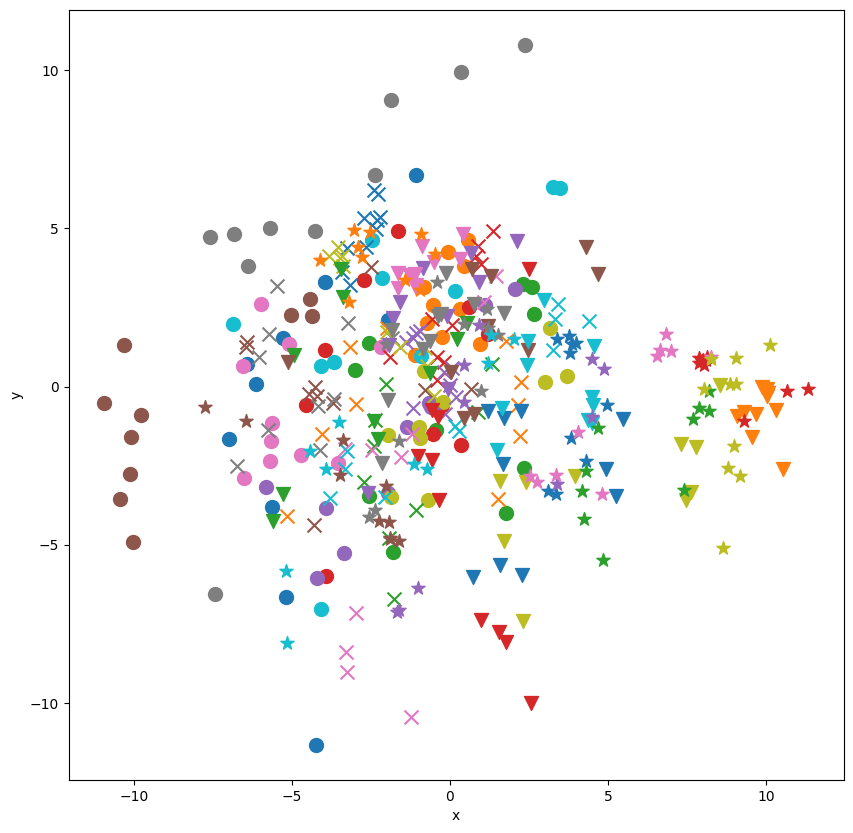

In [17]:
# Plot of projected points onto two dimensions. The color What do you observe?
plt.figure(figsize=(10,10))
x_points = project_to_principal_components(shifted_data, eigenvectors[:, :2])[:,0]
y_points = project_to_principal_components(shifted_data, eigenvectors[:, :2])[:,1]
color = [f"C{i}" for i in range(10)]
marker_styles = ["o" , "x", "v", "*", "8", "P", "D", "p", "s", "X", "."]
for i in range(len(np.unique(dataset.target))):
    plt.scatter(
        x_points[dataset.target == i],
        y_points[dataset.target == i],
        color=color[i % 10],
        marker=marker_styles[i // 10],
        s=100
    )
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## <span style="color:red">[TODO]</span> Reconstruct with limited number of components (3 pts)

We now want to reconstruct some faces from a limited number of components to asses how well they are compressed by projecting onto PCA components.

In [18]:
mean_face = np.mean(data, axis=0)
def reconstruct_from_principal_components(projected_data, eigenvectors, data_mean):
    """
    Reconstruct data from (first) principal components.

    Args:
        projected_data: An n x m array with the data projected on the first m principal components.
        eigenvectors: A k x m array with the first m ordered principal components of dim k.
        data_mean: A k array with the mean of the full dataset.
    
    Returns:
        Data reconstructed from the first m principal components.
    """
    ### BEGIN SOLUTION
    return projected_data.dot(eigenvectors.T) + mean_face
    ### END SOLUTION

Let's plot the first face reconstructed with only the mean face, and then successively add principal components when reconstructing. You can play around with the `face_id` to try out different faces.

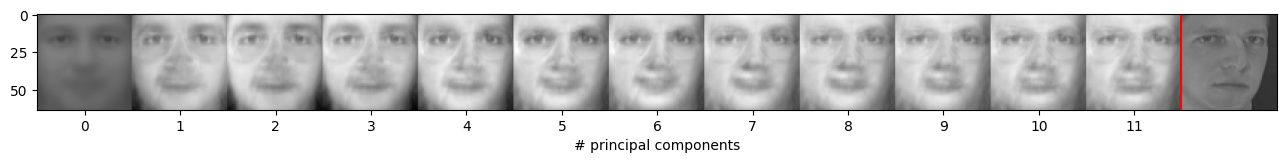

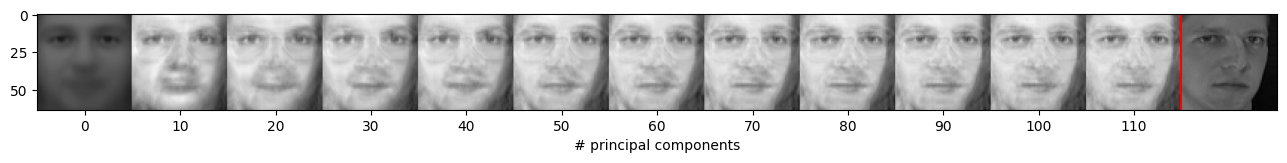

In [19]:
max_num_components = 120
face_id = 1
projected_data = project_to_principal_components(data, eigenvectors[:, :max_num_components])
reconstructions = []
for i in range(max_num_components):
    reconstructed_data = reconstruct_from_principal_components(projected_data[face_id, :i], eigenvectors[:, :i], mean_face)
    reconstructions.append(reconstructed_data)
def plot_faces(faces, stride=1):
    # Only show every stride-th reconstruction
    faces = faces[::stride]
    # Append ground truth face to the end
    faces.append(data[face_id])
    faces = np.array(faces)
    fig = plt.figure(figsize=(16, 4))
    plt.imshow(np.concatenate(faces.reshape((-1, 64, 64)), axis=1), cmap="gray")
    # Add vertical line to separate the ground truth face from the reconstructions
    plt.axvline((len(faces) - 1) * 64 - 0.5, color="red")
    # set x ticks to count the number of principal components
    plt.xticks(np.arange(len(faces)) * 64 - 32, (np.arange(len(faces)) - 1) * stride)
    plt.xlim(0, len(faces) * 64)
    plt.xlabel("# principal components")
    plt.show()
# Plot the reconstructions while successively adding one more principal component. What do you observe?
plot_faces(reconstructions[:12], stride=1)
# Plot the reconstructions while successively adding 10 more principal components. What do you observe?
plot_faces(reconstructions, stride=10)

We finally plot the first principal components. Is it possible to interpret some of them?

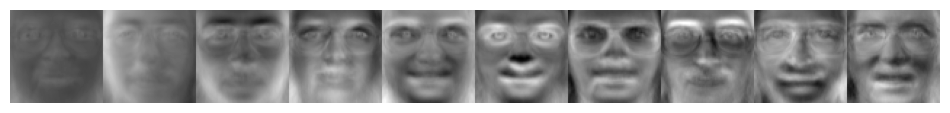

In [20]:
# Show first 10 eigenfaces/principal components
fig = plt.figure(figsize=(12, 6))
plt.imshow(np.concatenate(eigenvectors.T[:10].reshape((-1, 64, 64)), axis=1), cmap="gray")
plt.axis('off')
plt.show()